# Multiple Regression

## Overview

Extends OLS to multiple predictors. Each coefficient is a **partial effect**: the expected change in y per unit increase in x_j, holding all other predictors constant.

**Key concerns:**

| Issue | Detection | Remedy |
|---|---|---|
| Multicollinearity | VIF > 10 | Remove/combine correlated predictors |
| Overfitting | Train vs test R-squared gap | Regularisation, cross-validation |
| Confounding | DAG / theory | Include relevant covariates |
| Influential points | Cook's distance | Investigate, do not auto-remove |

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

rng = np.random.default_rng(42)
n = 150
elevation   = rng.uniform(50, 400, n)
nitrate     = rng.gamma(2, 2, n)
phosphorus  = 0.4*nitrate + rng.normal(0, 0.5, n)  # correlated with nitrate
treatment   = rng.choice([0,1], n)
richness    = (28 - 0.035*elevation - 0.8*nitrate
               + 2.5*treatment + rng.normal(0, 3.5, n))

df = pd.DataFrame({"richness":richness,"elevation":elevation,
                   "nitrate":nitrate,"phosphorus":phosphorus,"treatment":treatment})

---
## Fitting a Multiple Regression Model

In [2]:
X = sm.add_constant(df[["elevation","nitrate","treatment"]])
model = sm.OLS(df["richness"], X).fit()
print(model.summary())
print("\nPartial effects (all else held constant):")
for var, coef, (lo, hi) in zip(model.params.index, model.params, model.conf_int().values):
    print(f"  {var:12s}: {coef:+.3f}  95% CI [{lo:.3f}, {hi:.3f}]")

                            OLS Regression Results                            
Dep. Variable:               richness   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     91.91
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.85e-33
Time:                        20:42:22   Log-Likelihood:                -398.25
No. Observations:                 150   AIC:                             804.5
Df Residuals:                     146   BIC:                             816.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.0870      0.866     33.590      0.0

---
## Multicollinearity: VIF

In [3]:
# Include phosphorus to demonstrate collinearity with nitrate
X_vif = sm.add_constant(df[["elevation","nitrate","phosphorus","treatment"]])
vif_df = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_df.round(2))
print("\nVIF > 10 indicates problematic collinearity.")
print("nitrate and phosphorus are correlated -> one should be dropped or combined.")

     variable   VIF
0       const  9.26
1   elevation  1.00
2     nitrate  6.71
3  phosphorus  6.70
4   treatment  1.00

VIF > 10 indicates problematic collinearity.
nitrate and phosphorus are correlated -> one should be dropped or combined.


---
## Standardised Coefficients

In [4]:
# Standardise predictors to compare effect sizes across variables on different scales
X_std = df[["elevation","nitrate","treatment"]].copy()
X_std[["elevation","nitrate"]] = (X_std[["elevation","nitrate"]]
    - X_std[["elevation","nitrate"]].mean()) / X_std[["elevation","nitrate"]].std()
model_std = sm.OLS(df["richness"], sm.add_constant(X_std)).fit()
print("Standardised coefficients (one SD change in predictor -> this change in richness):")
for v, c in zip(model_std.params.index[1:], model_std.params[1:]):
    print(f"  {v:12s}: {c:+.3f}")

Standardised coefficients (one SD change in predictor -> this change in richness):
  elevation   : -3.572
  nitrate     : -2.826
  treatment   : +2.104


---
## Residual Diagnostics

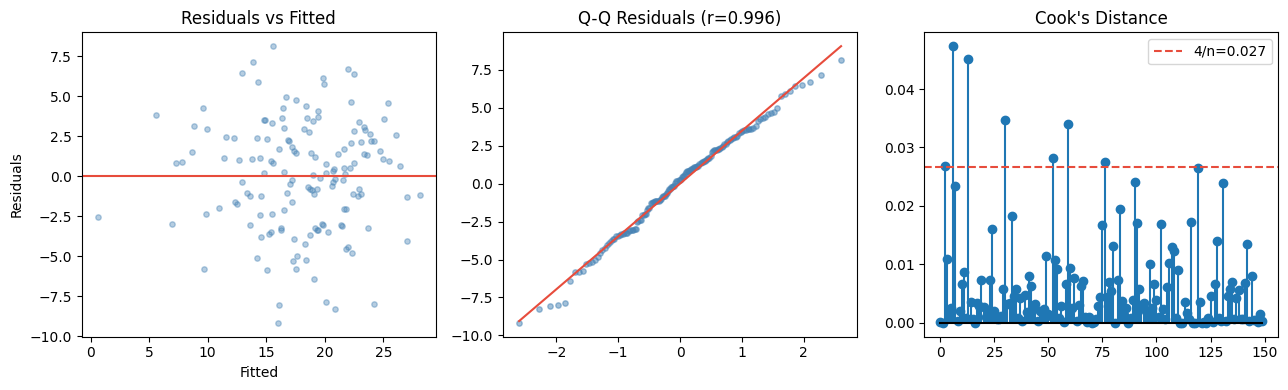

High influence points (Cook's d > 4/n): 7


In [5]:
fig, axes = plt.subplots(1,3,figsize=(13,4))
# Residuals vs fitted
resid = model.resid; fitted = model.fittedvalues
axes[0].scatter(fitted, resid, alpha=0.4, s=15, color="steelblue")
axes[0].axhline(0, color="#e74c3c", lw=1.5)
axes[0].set_title("Residuals vs Fitted"); axes[0].set_xlabel("Fitted"); axes[0].set_ylabel("Residuals")
# Q-Q
(osm,osr),(sl,ic,r) = stats.probplot(resid, dist="norm")
axes[1].scatter(osm, osr, s=15, alpha=0.5, color="steelblue")
axes[1].plot(osm, sl*np.array(osm)+ic, color="#e74c3c", lw=1.5)
axes[1].set_title(f"Q-Q Residuals (r={r:.3f})")
# Cook's distance
influence = model.get_influence()
cooks = influence.cooks_distance[0]
axes[2].stem(range(len(cooks)), cooks, markerfmt="C0o", linefmt="C0-", basefmt="k-")
axes[2].axhline(4/n, color="#e74c3c", lw=1.5, linestyle="--", label=f"4/n={4/n:.3f}")
axes[2].set_title("Cook's Distance"); axes[2].legend()
plt.tight_layout(); plt.show()
print(f"High influence points (Cook's d > 4/n): {(cooks > 4/n).sum()}")

---

## Common Pitfalls

**1. Interpreting coefficients without accounting for other predictors**  
Each coefficient in multiple regression is a partial effect — the change in y per unit x holding all else constant. Reporting it as a simple bivariate effect ignores the conditioning on other predictors.

**2. Including correlated predictors without checking VIF**  
High collinearity inflates standard errors, making coefficients individually unreliable even when the model fits well. Always compute VIFs. For VIF > 10, drop or combine the correlated predictors.

**3. Comparing raw coefficients across predictors on different scales**  
A coefficient of -0.035 for elevation (range 50-400m) and -0.8 for nitrate (range 0-20) are not directly comparable. Standardise predictors before comparing effect sizes.

**4. Ignoring Cook's distance and influential observations**  
A single high-leverage point can substantially shift all regression coefficients. Always inspect Cook's distance (flag > 4/n) and investigate flagged points before removing them.

**5. Using adjusted R-squared to compare models with different predictors without cross-validation**  
Adjusted R-squared penalises for model complexity but still increases with noise predictors on training data. Use held-out test data or cross-validation to compare models fairly.

---
*python_methods_library - Samantha McGarrigle*